data collection

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
np.random.seed(42)
study_hours=np.random.uniform(1,10,100)
marks=10*study_hours+np.random.normal(0,5,100)

df = pd.DataFrame({
    "StudyHours":study_hours.round(2),
    "Marks":marks.round(2)
})
df


,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


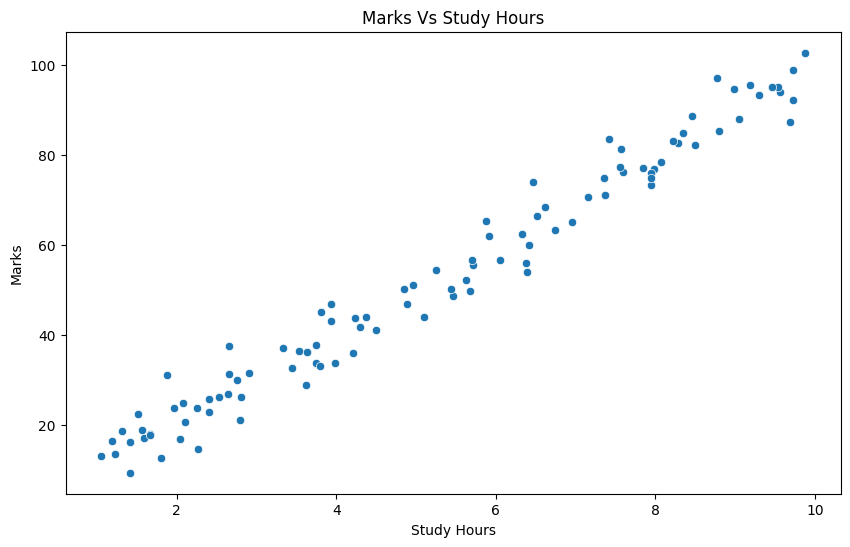

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="StudyHours",y="Marks")
plt.title("Marks Vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

data cleaning

In [ ]:
df.head()

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94


In [ ]:
df.tail()

,StudyHours,Marks
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67
99,1.97,23.85


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudyHours  100 non-null    float64
 1   Marks       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [ ]:
df.describe()

,StudyHours,Marks
count,100.000000,100.000000
mean,5.232100,52.311100
std,2.677397,26.477629
min,1.050000,9.470000
25%,2.735000,29.730000
50%,5.175000,49.990000
75%,7.575000,76.092500
max,9.880000,102.730000


In [ ]:
df.isnull().sum()

,0
StudyHours,0
Marks,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [ ]:
df.dropna()

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [ ]:
df.dtypes

,0
StudyHours,float64
Marks,float64


In [ ]:
df.shape

(100, 2)

train the model

In [ ]:
x=df[["StudyHours"]]
y=df[["Marks"]]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

Test model

In [ ]:
y_pred=model.predict(x_test)

evaluate model

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
mse=mean_absolute_error(y_test,y_pred)
mse

2.9480370450598263

In [ ]:
mse=mean_squared_error(y_test,y_pred)
mse

16.262700706811483

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.9784699264524137

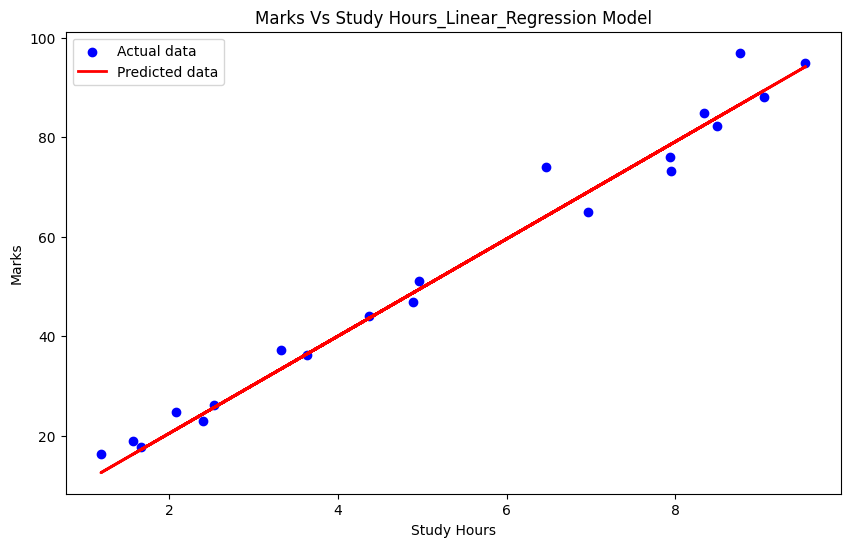

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(x_test,y_test,color="blue",label="Actual data")
plt.plot(x_test,y_pred,color="red",linewidth=2,label="Predicted data")
plt.title("Marks Vs Study Hours_Linear_Regression Model")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.show()

In [ ]:
new_hours=[[7.5]]
predicted_marks=model.predict(new_hours)
print(predicted_marks.round(2))

[[74.26]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print("slpoe(co - efficence):",model.coef_[0])


slpoe(co - efficence): [9.77619009]


In [ ]:
print("Intercept:",model.intercept_)


Intercept: [0.93620797]


In [ ]:
print("\n Regression Equation:")
# Notice the [0][0] to extract the number out of the 2D array
print(f"marks = {model.coef_[0][0]:.2f} * Study hours {model.intercept_[0]:+.2f}")


 Regression Equation:
marks = 9.78 * Study hours +0.94


In [9]:
import joblib
joblib.dump(model,"Linear_Regression_model.pkl")

print("model generated")

ModuleNotFoundError: No module named 'joblib'